In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import seaborn as sns
import plotly.express as px
import sklearn.preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
import sklearn.metrics as mt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import random


In [3]:
df1 = pd.read_csv(r'onlyDEGs_BatchCorrected_GEO_TCGA_normalized.csv')
df1 = df1[df1['Subtype'] != 'NORMAL']
df1.set_index('File_Name', inplace=True)
df1

,TNFRSF18,GINS1,FXYD6-FXYD2,FANCB,SEMA3G,THRSP,SERPINA6,ALB,CYP4F8,CAPN11,...,SIM2,SEMA6D,TMEM255A,MAST4,ID4,TRIM63,TNIP3,ZBTB16,NWD2,Subtype
File_Name,,,,,,,,,,,,,,,,,,,,,
GSM2310628_B3.CEL,6.427248,8.375485,6.858164,6.509938,7.304669,5.379885,1.064453,2.095593,2.848981,3.738669,...,2.975163,4.133677,4.391101,8.107904,11.268210,2.211828,3.999714,4.283295,1.530195,M
GSM2310633_B89.CEL,4.625862,8.071895,7.035507,5.402198,7.194103,4.148475,0.211628,4.099804,3.007884,3.699159,...,5.923182,5.588119,6.513145,8.620075,8.677983,3.127686,3.611067,5.487459,2.415367,BL1
GSM2310634_B91.CEL,5.835884,7.901510,7.039320,7.429637,7.312906,5.147304,3.095725,4.262841,3.570077,4.216438,...,7.348662,5.504950,5.429406,7.615105,6.952951,4.019450,4.151110,5.715522,3.113641,BL1
GSM2310636_BP45.CEL,7.386628,8.582149,6.793678,7.883659,7.027723,6.584807,0.306810,3.193610,3.032765,4.161595,...,5.104929,4.991422,4.019421,8.645671,8.171196,2.793432,4.777972,5.098561,0.718888,M
GSM2310637_BP46.CEL,5.295109,7.678955,6.461987,6.084640,6.507425,4.444928,3.087694,3.809190,3.554265,4.440428,...,3.886117,6.047982,3.683043,9.250161,7.613686,2.791577,4.028000,5.376216,2.749895,BL1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ffeede9a-d9a9-4836-8c56-39f12a5fde0e,8.675916,9.100970,0.000000,5.541770,10.132583,6.301828,12.715403,5.561346,4.207274,4.162878,...,3.130006,7.500764,6.742432,10.485268,7.272515,2.524557,2.057869,8.028746,0.671130,nonTNBC
63454d5d-a654-4be0-b812-dd5c98d07ea1,5.306161,6.939625,0.000000,4.346441,8.496149,11.616728,1.922213,2.407389,7.659312,4.389154,...,3.468688,6.988667,7.030531,9.256492,6.917066,2.863588,1.657198,11.224823,0.671130,nonTNBC
158cc60a-89b0-40f0-8536-8c0f0e31429b,9.053194,6.231417,0.000000,3.838760,8.868503,8.616982,10.283382,2.957510,3.909635,4.622126,...,3.731390,6.629086,5.212581,8.738033,6.616319,2.046719,2.357134,6.558188,3.925088,nonTNBC


In [5]:
df1['Subtype'].value_counts()


Subtype
nonTNBC    291
BL1        160
M          151
LAR        106
BL2         75
Name: count, dtype: int64

# **Train Test Split**

In [8]:
df2 =pd.read_csv(r'Filename_with_Subtype_All_Datasets.csv')

#Put GSE ids for the datasets you want to include in the test set
GSE_Test_ids = df2[(df2['Dataset'] == 'GSE86946') | (df2['Dataset'] == 'GSE176128')] 
test_ids = GSE_Test_ids['File_Name'].to_list()

#Add 60 nonTNBC samples to the test set
NT_Test_ids = df2[df2['Subtype'] == 'nonTNBC'].sample(n=60, random_state=42)
test_ids.extend(NT_Test_ids['File_Name'].to_list())


In [10]:
# Test samples
test_df = df1.loc[df1.index.isin(test_ids)]

# Train samples = everything else
train_df = df1.loc[~df1.index.isin(test_ids)]

In [12]:
train_df['Subtype'].value_counts()

Subtype
nonTNBC    231
BL1        145
M          125
LAR         94
BL2         62
Name: count, dtype: int64

In [13]:
test_df['Subtype'].value_counts()

Subtype
nonTNBC    60
M          26
BL1        15
BL2        13
LAR        12
Name: count, dtype: int64

Class distribution after SMOTE:
Subtype
nonTNBC    231
M          200
BL1        200
LAR        200
BL2        200
Name: count, dtype: int64

Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         BL1       0.60      0.80      0.69        15
         BL2       0.40      0.15      0.22        13
         LAR       0.71      0.83      0.77        12
           M       0.67      0.77      0.71        26
     nonTNBC       1.00      0.95      0.97        60

    accuracy                           0.80       126
   macro avg       0.68      0.70      0.67       126
weighted avg       0.79      0.80      0.79       126



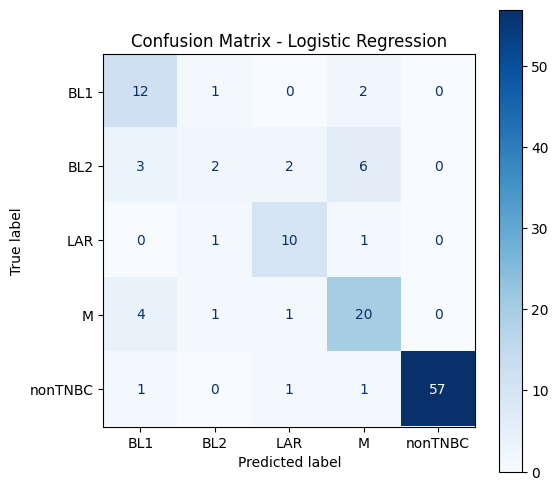


Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   support

         BL1       0.39      0.47      0.42        15
         BL2       0.33      0.31      0.32        13
         LAR       0.67      0.83      0.74        12
           M       0.58      0.54      0.56        26
     nonTNBC       1.00      0.95      0.97        60

    accuracy                           0.73       126
   macro avg       0.59      0.62      0.60       126
weighted avg       0.74      0.73      0.73       126



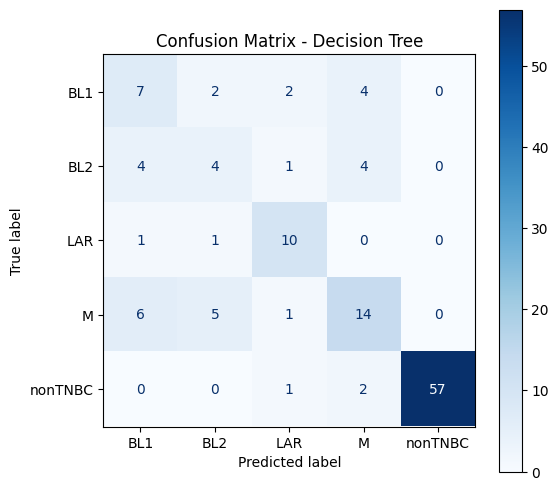


Training Random Forest...

Classification Report for Random Forest:
              precision    recall  f1-score   support

         BL1       0.83      1.00      0.91        15
         BL2       0.91      0.77      0.83        13
         LAR       1.00      1.00      1.00        12
           M       0.96      1.00      0.98        26
     nonTNBC       1.00      0.97      0.98        60

    accuracy                           0.96       126
   macro avg       0.94      0.95      0.94       126
weighted avg       0.96      0.96      0.96       126



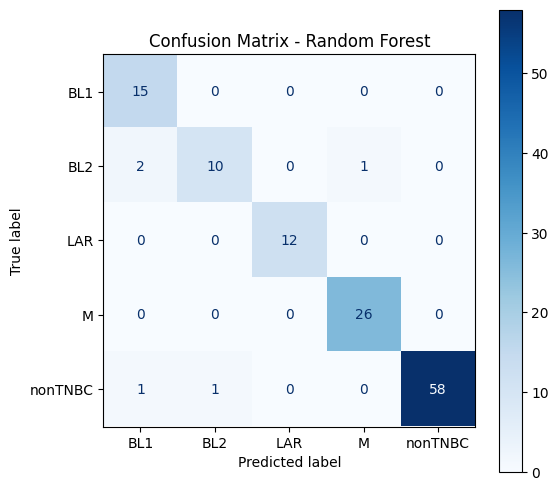


Training AdaBoost...


C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



Classification Report for AdaBoost:
              precision    recall  f1-score   support

         BL1       0.50      0.07      0.12        15
         BL2       0.20      1.00      0.33        13
         LAR       0.00      0.00      0.00        12
           M       0.00      0.00      0.00        26
     nonTNBC       1.00      0.98      0.99        60

    accuracy                           0.58       126
   macro avg       0.34      0.41      0.29       126
weighted avg       0.56      0.58      0.52       126



C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


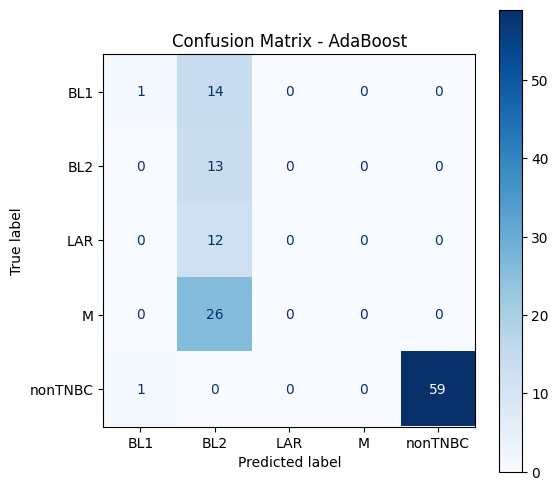


Training Gradient Boosting...

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

         BL1       0.75      1.00      0.86        15
         BL2       0.80      0.62      0.70        13
         LAR       1.00      1.00      1.00        12
           M       1.00      0.92      0.96        26
     nonTNBC       1.00      1.00      1.00        60

    accuracy                           0.94       126
   macro avg       0.91      0.91      0.90       126
weighted avg       0.95      0.94      0.94       126



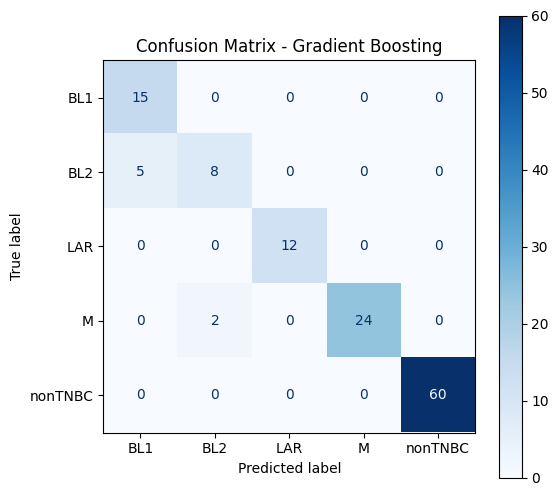


Training SVM...

Classification Report for SVM:
              precision    recall  f1-score   support

         BL1       0.88      1.00      0.94        15
         BL2       0.88      0.54      0.67        13
         LAR       0.85      0.92      0.88        12
           M       0.81      1.00      0.90        26
     nonTNBC       1.00      0.93      0.97        60

    accuracy                           0.91       126
   macro avg       0.88      0.88      0.87       126
weighted avg       0.92      0.91      0.91       126



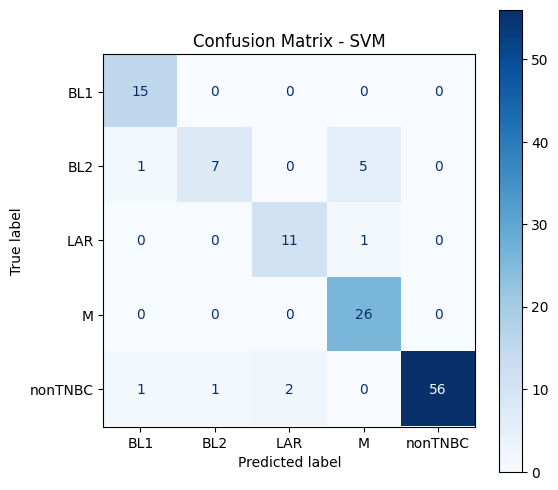


Training K-Nearest Neighbors...

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

         BL1       0.82      0.93      0.88        15
         BL2       0.86      0.92      0.89        13
         LAR       0.65      0.92      0.76        12
           M       0.92      0.92      0.92        26
     nonTNBC       1.00      0.87      0.93        60

    accuracy                           0.90       126
   macro avg       0.85      0.91      0.87       126
weighted avg       0.91      0.90      0.90       126



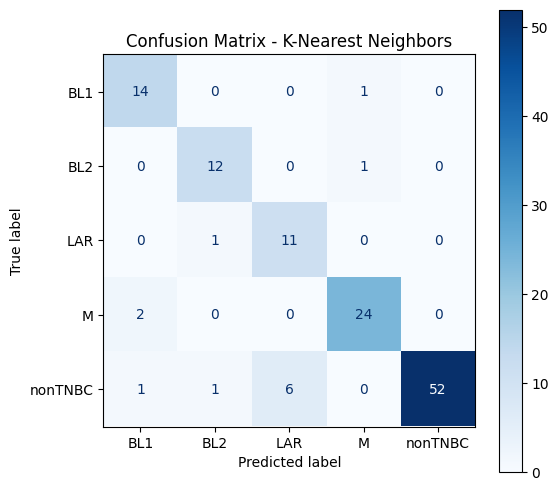


Training Gaussian Naive Bayes...

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

         BL1       0.36      0.53      0.43        15
         BL2       0.43      0.23      0.30        13
         LAR       0.62      0.67      0.64        12
           M       0.68      0.65      0.67        26
     nonTNBC       1.00      0.98      0.99        60

    accuracy                           0.75       126
   macro avg       0.62      0.61      0.61       126
weighted avg       0.76      0.75      0.75       126



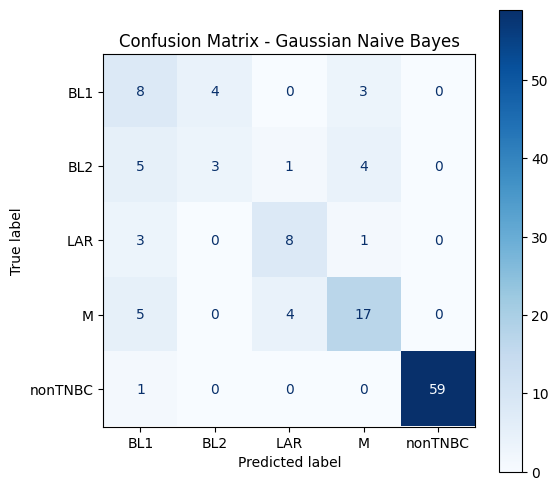


 Accuracy Results:
                  Model  Train Accuracy  Test Accuracy
0         Random Forest        1.000000       0.960317
1     Gradient Boosting        1.000000       0.944444
2                   SVM        0.946654       0.912698
3   K-Nearest Neighbors        0.939864       0.896825
4   Logistic Regression        1.000000       0.801587
5  Gaussian Naive Bayes        0.738118       0.753968
6         Decision Tree        1.000000       0.730159
7              AdaBoost        0.425800       0.579365


In [16]:


# -----------------------------
# 1. Prepare Train and Test Data
# -----------------------------
X_train = train_df.drop(columns=['Subtype'])
y_train = train_df['Subtype']

X_test = test_df.drop(columns=['Subtype'])
y_test = test_df['Subtype']

# Apply SMOTE to balance training data
smote = SMOTE(sampling_strategy={'BL1':200, 'M':200, 'LAR':200, 'BL2':200})
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

# -----------------------------
# 2. Define Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB()
}

results = {'Model': [], 'Train Accuracy': [], 'Test Accuracy': []}

# -----------------------------
# 3. Train & Evaluate Each Model
# -----------------------------
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    
    # Predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    
    # Accuracy
    train_accuracy = accuracy_score(y_train_resampled, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    results['Model'].append(name)
    results['Train Accuracy'].append(train_accuracy)
    results['Test Accuracy'].append(test_accuracy)
    
    # Print classification report
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_test_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# -----------------------------
# 4. Show Summary of Accuracies
# -----------------------------
results_df = pd.DataFrame(results)
print("\n Accuracy Results:")
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df)


In [ ]:
results

In [ ]:
results_df

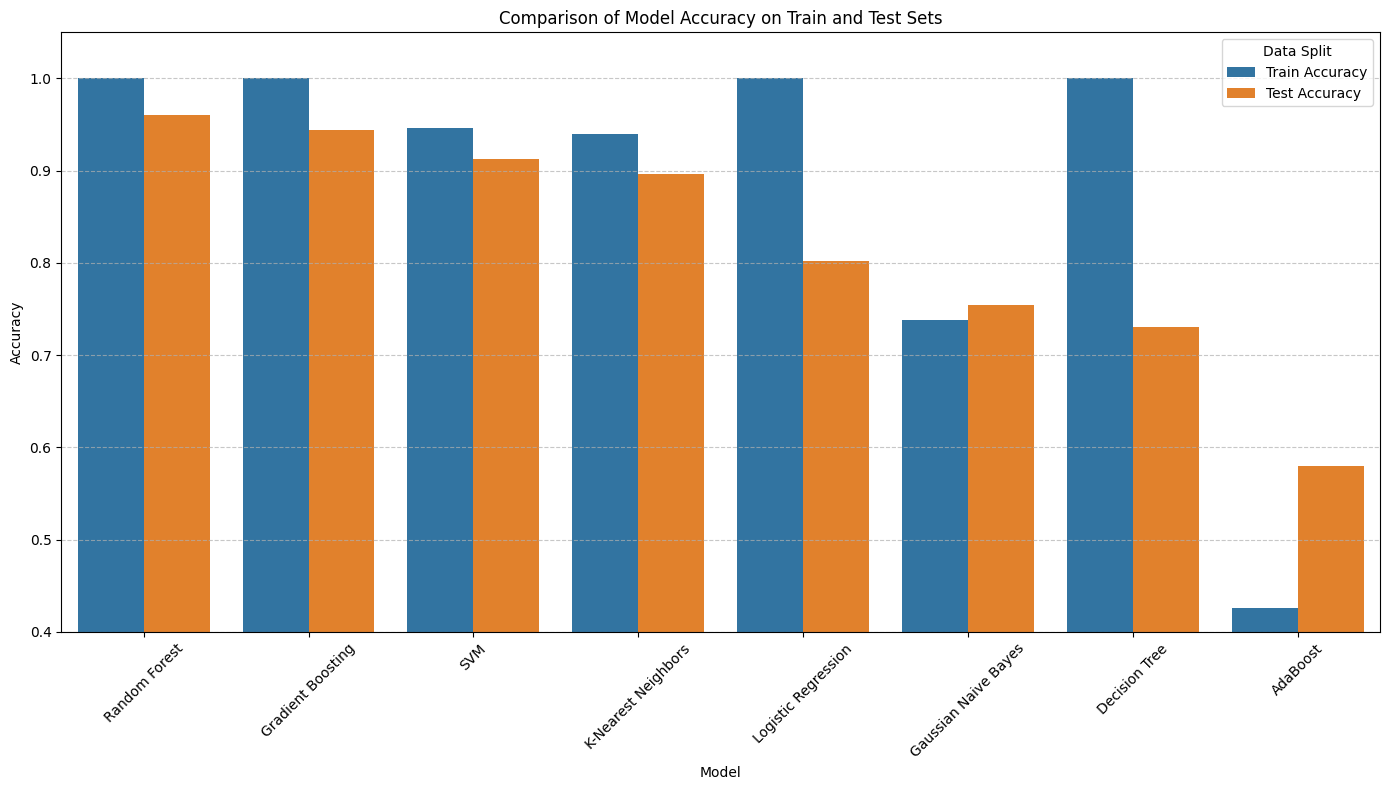

In [19]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Reshape for Seaborn plotting
results_df_melted = results_df.melt(id_vars='Model', var_name='Set', value_name='Accuracy')

# 3️Sort by test set accuracy
test_sorted = results_df_melted[results_df_melted['Set'] == 'Test Accuracy']
sorted_order = test_sorted.sort_values(by='Accuracy', ascending=False)['Model'].tolist()

#  Plot with sorted order
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Accuracy', hue='Set', data=results_df_melted, order=sorted_order)
plt.xticks(rotation=45)
plt.title('Comparison of Model Accuracy on Train and Test Sets')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1.05)
plt.legend(title='Data Split')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Encode target labels for ROC curve (multiclass)
classes = sorted(y_train.unique())  # ['BL1', 'BL2', 'LAR', 'M','nonTNBC']
y_test_bin = label_binarize(y_test, classes=classes)
y_train_bin = label_binarize(y_train_resampled, classes=classes)

# Initialize for ROC curves
plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\n📈 Cross-validation for {name}...")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_resampled, y_train_resampled, cv=10)
    print(f" Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit and predict probabilities for ROC
    classifier = OneVsRestClassifier(model)
    classifier.fit(X_train_resampled, y_train_bin)
    y_score = classifier.predict_proba(X_test)

  


📈 Cross-validation for Logistic Regression...
 Mean CV Accuracy: 0.8846 ± 0.0710

📈 Cross-validation for Decision Tree...
 Mean CV Accuracy: 0.8254 ± 0.0746

📈 Cross-validation for Random Forest...
 Mean CV Accuracy: 0.9641 ± 0.0246

📈 Cross-validation for AdaBoost...


C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jom

 Mean CV Accuracy: 0.4403 ± 0.0234


C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jomyf\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\jom


📈 Cross-validation for Gradient Boosting...


KeyboardInterrupt: 

<Figure size 1000x800 with 0 Axes>

In [27]:
model.classes_

array(['BL1', 'BL2', 'LAR', 'M', 'nonTNBC'], dtype=object)

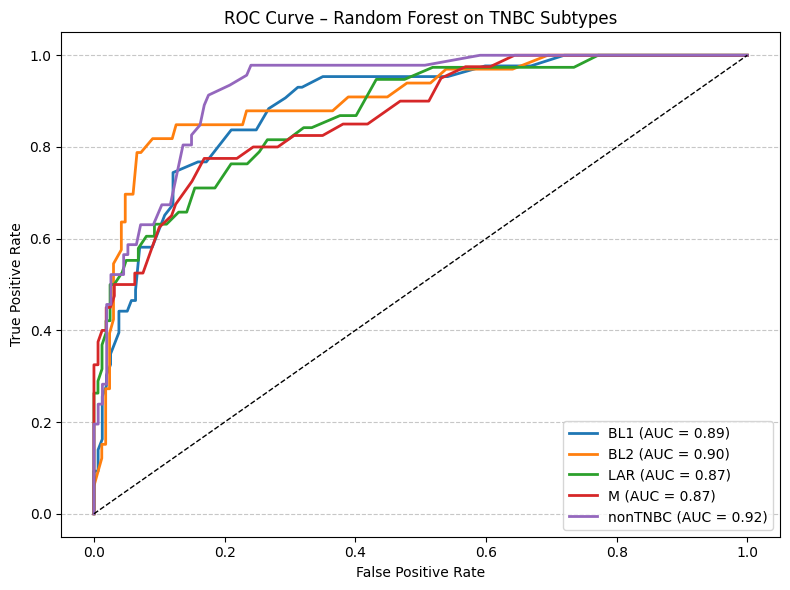

In [29]:
import os
import time
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.datasets import make_classification
from sklearn.multiclass import OneVsRestClassifier

# Simulate TNBC-like data – replace with actual molecular dataset
X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=5,
    n_informative=10, random_state=42
)
class_names = ['BL1', 'BL2', 'LAR', 'M', 'nonTNBC']
y_bin = label_binarize(y, classes=[0, 1, 2, 3, 4])

# Split data (important for ROC eval)
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# Train One-vs-Rest Random Forest
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
ovr_model = OneVsRestClassifier(rf)
ovr_model.fit(X_train, y_train)
train_time = time.time() - start_time

# Save model and check size
joblib.dump(ovr_model, 'rf_tnbc_model.joblib')
model_size_kb = round(os.path.getsize('rf_tnbc_model.joblib') / 1024, 2)

# Predict probabilities for each class
probas = ovr_model.predict_proba(X_test)

# Plot ROC curve per TNBC subtype
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest on TNBC Subtypes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("tnbc_roc_curve.png", dpi=300)  # Adjust DPI for resolution
plt.show()

plt.close()  


In [ ]:
import os
import time
import joblib
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


#  Models to evaluate
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'AdaBoost': AdaBoostClassifier()
}

results = {}

#  Measure training time & model size
for name, model in models.items():
    print(f"\n Training {name}...")
    start_time = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    train_time = round(time.time() - start_time, 2)

    # Save model and measure file size
    file_name = f"{name.replace(' ', '_')}.joblib"
    joblib.dump(model, file_name)
    model_size_kb = round(os.path.getsize(file_name) / 1024, 2)

    # Store results
    results[name] = {
        'Training Time (s)': train_time,
        'Model Size (KB)': model_size_kb
    }

#  Summary
print("\n Benchmark Summary:")
for name, metrics in results.items():
    print(f"{name}: Training Time = {metrics['Training Time (s)']} s, Model Size = {metrics['Model Size (KB)']} KB")